In [26]:
# 1 Train a simple neural network using Keras on the Fashion MNIST dataset and plot both training loss and validation loss for each epoch using matplotlib.

import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score


In [2]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

X_train = X_train / 255.0
X_test = X_test / 255.0

In [3]:
model = Sequential([Flatten(input_shape=(28, 28)),Dense(128, activation='relu'),Dense(10, activation='softmax')])

c:\Users\skadi\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [4]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [5]:
history = model.fit(X_train, y_train,epochs=5,validation_data=(X_test, y_test))

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8260 - loss: 0.4997 - val_accuracy: 0.8549 - val_loss: 0.4103
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8648 - loss: 0.3773 - val_accuracy: 0.8576 - val_loss: 0.4011
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8762 - loss: 0.3398 - val_accuracy: 0.8673 - val_loss: 0.3636
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8843 - loss: 0.3144 - val_accuracy: 0.8735 - val_loss: 0.3522
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8898 - loss: 0.2976 - val_accuracy: 0.8709 - val_loss: 0.3586


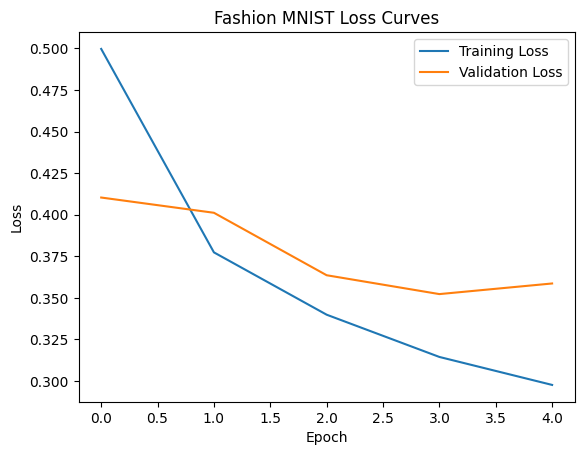

In [6]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Fashion MNIST Loss Curves')
plt.legend()
plt.show()

In [7]:
# 2 Intentionally overfit a small neural network on a subset of the Fashion MNIST data (e.g., only 500 samples) and describe two signs from your loss curves that indicate overfitting.<br><br><em><strong>Hint:</strong> Look for divergence between training and validation loss after a certain number of epochs.</em>

# Use only 500 samples
X_train = X_train[:500] / 255.0
y_train = y_train[:500]

X_test = X_test / 255.0



In [ ]:
# Larger model to encourage overfitting
model = Sequential([Flatten(input_shape=(28, 28)),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

In [9]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [10]:
history = model.fit(X_train, y_train,epochs=30,validation_data=(X_test, y_test))

Epoch 1/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.1060 - loss: 2.2993 - val_accuracy: 0.1974 - val_loss: 2.2890
Epoch 2/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.4000 - loss: 2.2753 - val_accuracy: 0.3842 - val_loss: 2.2526
Epoch 3/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.4120 - loss: 2.2184 - val_accuracy: 0.4072 - val_loss: 2.1670
Epoch 4/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.4020 - loss: 2.1000 - val_accuracy: 0.3970 - val_loss: 2.0088
Epoch 5/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.4040 - loss: 1.9192 - val_accuracy: 0.4408 - val_loss: 1.8140
Epoch 6/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.4200 - loss: 1.7237 - val_accuracy: 0.4480 - val_loss: 1.6204
Epoch 7/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.5280 - loss: 1.5539 - val_accuracy: 0.5183 - val_loss: 1.4795
Epoch 8/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.4980 - loss: 1.4336 - val_accuracy: 0.5408 - v

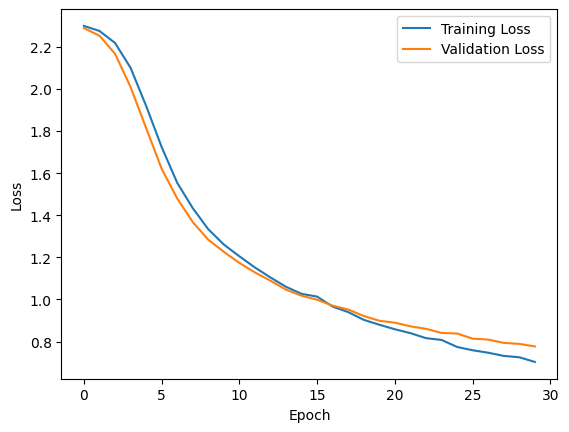

In [11]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [13]:
# 3 Add an EarlyStopping callback to your Keras model training so that it stops if validation loss does not improve for 3 consecutive epochs, and report after how many epochs the training stopped.

(X_train, y_train), (X_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

X_train = X_train[:500] / 255.0  # small subset
y_train = y_train[:500]
X_test = X_test / 255.0

In [14]:
# Model
model = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

In [ ]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [ ]:
# Early Stopping
early_stop = EarlyStopping(monitor='val_loss',patience=3,restore_best_weights=True)

In [ ]:
# Train
history = model.fit(X_train, y_train,epochs=30,validation_data=(X_test, y_test),callbacks=[early_stop])

Epoch 1/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.4880 - loss: 1.5598 - val_accuracy: 0.6164 - val_loss: 1.1079
Epoch 2/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.6960 - loss: 0.8846 - val_accuracy: 0.6282 - val_loss: 0.9626
Epoch 3/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.7680 - loss: 0.7009 - val_accuracy: 0.6893 - val_loss: 0.8713
Epoch 4/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.8160 - loss: 0.5604 - val_accuracy: 0.7077 - val_loss: 0.8278
Epoch 5/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8560 - loss: 0.4866 - val_accuracy: 0.7333 - val_loss: 0.7610
Epoch 6/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.8740 - loss: 0.4214 - val_accuracy: 0.7390 - val_loss: 0.7170
Epoch 7/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.8540 - loss: 0.4249 - val_accuracy: 0.7618 - val_loss: 0.7280
Epoch 8/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8960 - loss: 0.3305 - val_accuracy: 0.7736 - v

In [18]:
print("Training stopped after", len(history.history['loss']), "epochs")

Training stopped after 12 epochs


In [19]:
# 4 After training your Fashion MNIST model, calculate and print the accuracy, precision, and recall for the test set using scikit-learn's metrics functions.

X_train = X_train / 255.0
X_test = X_test / 255.0


In [20]:
# Model
model = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

In [ ]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [22]:
model.fit(X_train, y_train, epochs=5, verbose=1)

Epoch 1/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.1480 - loss: 2.2984  
Epoch 2/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3920 - loss: 2.2843 
Epoch 3/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4540 - loss: 2.2646 
Epoch 4/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4500 - loss: 2.2391 
Epoch 5/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5160 - loss: 2.2056 


In [25]:
y_pred = model.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 689us/step


In [27]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)

Accuracy : 0.5251
Precision: 0.5123596882674052
Recall   : 0.5251


c:\Users\skadi\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Epoch 1/5


c:\Users\skadi\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8240 - loss: 0.5045
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8638 - loss: 0.3755
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8779 - loss: 0.3364
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8856 - loss: 0.3115
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8923 - loss: 0.2935
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 704us/step
AUC Score: 0.9892237222222221


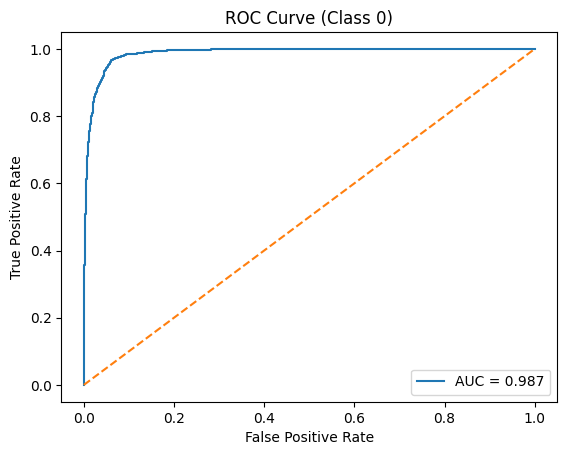

In [28]:
# 5 Compute and plot the ROC curve and AUC score for your model's predictions on the Fashion MNIST test set using scikit-learn.<br><br><em><strong>Hint:</strong> For multiclass, use the 'roc_auc_score' function with 'multi_class' parameter set to 'ovr'.</em>

from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.preprocessing import label_binarize

# Load Fashion MNIST
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

X_train = X_train / 255.0
X_test = X_test / 255.0

# Model
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28,28)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.fit(X_train, y_train, epochs=5, verbose=1)

# Predicted probabilities
y_pred_prob = model.predict(X_test)

# One-hot encode true labels
y_test_bin = label_binarize(y_test, classes=np.arange(10))

# AUC Score
auc_score = roc_auc_score(
    y_test_bin,
    y_pred_prob,
    multi_class='ovr'
)

print("AUC Score:", auc_score)

# ROC curve for Class 0
fpr, tpr, _ = roc_curve(y_test_bin[:, 0], y_pred_prob[:, 0])

plt.plot(fpr, tpr, label=f"AUC = {auc(fpr, tpr):.3f}")
plt.plot([0, 1], [0, 1], '--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Class 0)")
plt.legend()
plt.show()